# Day 063 — Association Rule Mining: Apriori & FP-Growth

> **Goal**: Association Rule Mining identifies hidden relationships and co-occurrence patterns in transaction data. Its primary application, **Market Basket Analysis**, powers recommendation engines by discovering rules like: "Customers who purchase bread and butter are highly likely to also purchase milk."


In [1]:
# ============================================================
# Setup & Imports
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print('All imports ready!')


All imports ready!


---
## 1. Market Basket Analysis — Concepts & Terminology

### 🛒 What is Market Basket Analysis?

Given a database of customer transactions, the goal is to extract implications of the form:

$$\{\text{Bread, Butter}\} \Rightarrow \{\text{Milk}\}$$

This rule indicates that transactions containing Bread and Butter frequently contain Milk as well.

### 📖 Core Terminology

| Term | Definition |
|------|------------|
| **Itemset** | A collection of one or more items, e.g., $\{\text{Milk, Bread}\}$. |
| **Transaction** | A single basket recorded at checkout. |
| **Frequent Itemset** | An itemset whose support satisfies a user-defined minimum support threshold. |
| **Association Rule** | An expression $A \Rightarrow B$, where $A$ (antecedent) and $B$ (consequent) are disjoint itemsets ($A \cap B = \emptyset$). |

### 🌍 Industry Applications

| Field | Application |
|-------|-------------|
| **Retail** | Product placement optimization, bundle promotional strategy |
| **E-Commerce** | Cross-selling recommendation engines ("Frequently Bought Together") |
| **Healthcare** | Symptom co-occurrence and adverse drug reaction monitoring |
| **Web Analytics** | Clickstream path pattern extraction |


In [2]:
# ── Create Transaction Dataset ──
transactions = [
    ['Milk', 'Bread', 'Butter'],
    ['Milk', 'Bread'],
    ['Milk', 'Diaper', 'Beer', 'Eggs'],
    ['Bread', 'Butter'],
    ['Milk', 'Bread', 'Butter', 'Diaper', 'Beer'],
    ['Milk', 'Diaper', 'Beer'],
    ['Bread', 'Butter', 'Eggs'],
    ['Milk', 'Bread', 'Diaper', 'Beer'],
    ['Milk', 'Bread', 'Butter', 'Eggs'],
    ['Bread', 'Butter', 'Diaper'],
]

print(f'Total Transactions: {len(transactions)}')
print(f'Unique Items: {sorted(set(item for t in transactions for item in t))}')
print()
for i, t in enumerate(transactions):
    print(f'  Transaction {i+1}: {t}')


Total Transactions: 10
Unique Items: ['Beer', 'Bread', 'Butter', 'Diaper', 'Eggs', 'Milk']

  Transaction 1: ['Milk', 'Bread', 'Butter']
  Transaction 2: ['Milk', 'Bread']
  Transaction 3: ['Milk', 'Diaper', 'Beer', 'Eggs']
  Transaction 4: ['Bread', 'Butter']
  Transaction 5: ['Milk', 'Bread', 'Butter', 'Diaper', 'Beer']
  Transaction 6: ['Milk', 'Diaper', 'Beer']
  Transaction 7: ['Bread', 'Butter', 'Eggs']
  Transaction 8: ['Milk', 'Bread', 'Diaper', 'Beer']
  Transaction 9: ['Milk', 'Bread', 'Butter', 'Eggs']
  Transaction 10: ['Bread', 'Butter', 'Diaper']


---
## 2. Core Metrics: Support, Confidence, Lift, Conviction & Leverage

### 📐 Mathematical Definitions

For an association rule $A \Rightarrow B$:

#### 1. Support — Co-occurrence Frequency

$$\text{Support}(A \cup B) = \frac{|\text{Transactions containing both } A \text{ and } B|}{|\text{Total Transactions}|} = P(A \cap B)$$

- Range: $[0, 1]$
- Measures how frequently an itemset appears in the dataset.

#### 2. Confidence — Conditional Probability

$$\text{Confidence}(A \Rightarrow B) = \frac{\text{Support}(A \cup B)}{\text{Support}(A)} = P(B \mid A)$$

- Range: $[0, 1]$
- Measures how often item $B$ appears in transactions that contain item $A$.

#### 3. Lift — Increase in Likelihood

$$\text{Lift}(A \Rightarrow B) = \frac{\text{Confidence}(A \Rightarrow B)}{\text{Support}(B)} = \frac{P(A \cap B)}{P(A) \cdot P(B)}$$

| Lift Value | Interpretation |
|------------|----------------|
| $> 1$ | **Positive correlation**: Purchase of $A$ increases likelihood of purchasing $B$. |
| $= 1$ | **Independence**: $A$ and $B$ occur together purely by chance. |
| $< 1$ | **Negative correlation**: Purchase of $A$ decreases likelihood of purchasing $B$. |

#### 4. Conviction — Rule Dependence

$$\text{Conviction}(A \Rightarrow B) = \frac{1 - \text{Support}(B)}{1 - \text{Confidence}(A \Rightarrow B)}$$

- Measures the expected frequency that $A$ occurs without $B$.

#### 5. Leverage — Deviation from Independence

$$\text{Leverage}(A \Rightarrow B) = \text{Support}(A \cup B) - \text{Support}(A) \cdot \text{Support}(B)$$

- Measures the difference between observed co-occurrence and expected independent co-occurrence.


In [3]:
# ── From-Scratch Metric Calculations ──

def get_support(itemset, transactions):
    count = sum(1 for t in transactions if set(itemset).issubset(set(t)))
    return count / len(transactions)

def get_confidence(antecedent, consequent, transactions):
    sup_ab = get_support(antecedent + consequent, transactions)
    sup_a = get_support(antecedent, transactions)
    return sup_ab / sup_a if sup_a > 0 else 0

def get_lift(antecedent, consequent, transactions):
    conf = get_confidence(antecedent, consequent, transactions)
    sup_b = get_support(consequent, transactions)
    return conf / sup_b if sup_b > 0 else 0

def get_conviction(antecedent, consequent, transactions):
    conf = get_confidence(antecedent, consequent, transactions)
    sup_b = get_support(consequent, transactions)
    if conf == 1.0:
        return float('inf')
    return (1 - sup_b) / (1 - conf)

def get_leverage(antecedent, consequent, transactions):
    sup_ab = get_support(antecedent + consequent, transactions)
    sup_a = get_support(antecedent, transactions)
    sup_b = get_support(consequent, transactions)
    return sup_ab - (sup_a * sup_b)

# Sample evaluation
rules_to_check = [
    (['Milk'], ['Bread']),
    (['Bread'], ['Butter']),
    (['Diaper'], ['Beer']),
    (['Milk', 'Bread'], ['Butter']),
    (['Beer'], ['Diaper']),
]

print('=' * 85)
print(f'{"Rule":30s} | {"Supp":>6s} | {"Conf":>6s} | {"Lift":>6s} | {"Conv":>6s} | {"Lev":>6s}')
print('=' * 85)

for ant, con in rules_to_check:
    rule_str = f'{ant} => {con}'
    supp = get_support(ant + con, transactions)
    conf = get_confidence(ant, con, transactions)
    lift = get_lift(ant, con, transactions)
    conv = get_conviction(ant, con, transactions)
    lev = get_leverage(ant, con, transactions)
    conv_str = f'{conv:.3f}' if conv != float('inf') else '  inf'
    print(f'{rule_str:30s} | {supp:6.3f} | {conf:6.3f} | {lift:6.3f} | {conv_str:>6s} | {lev:6.3f}')

print('=' * 85)


Rule                           |   Supp |   Conf |   Lift |   Conv |    Lev
['Milk'] => ['Bread']          |  0.500 |  0.714 |  0.893 |  0.700 | -0.060
['Bread'] => ['Butter']        |  0.600 |  0.750 |  1.250 |  1.600 |  0.120
['Diaper'] => ['Beer']         |  0.400 |  0.800 |  2.000 |  3.000 |  0.200
['Milk', 'Bread'] => ['Butter'] |  0.300 |  0.600 |  1.000 |  1.000 |  0.000
['Beer'] => ['Diaper']         |  0.400 |  1.000 |  2.000 |    inf |  0.200


---
## 3. The Apriori Algorithm

### 🔬 Algorithm Mechanics

The Apriori algorithm employs the **Apriori Property** (anti-monotonicity of support):

> **All non-empty subsets of a frequent itemset must also be frequent.**

$$\text{Support}(A) < \text{min\_support} \implies \forall B \supseteq A: \text{Support}(B) < \text{min\_support}$$

This property allows Apriori to **prune** candidate itemsets efficiently without scanning all possible combinations.

### 📋 Execution Steps:
1. **Pass 1**: Count support for individual 1-itemsets; discard itemsets below `min_support` $\rightarrow L_1$.
2. **Join Step**: Generate candidate $k$-itemsets $C_k$ from frequent $(k-1)$-itemsets $L_{k-1}$.
3. **Prune Step**: Remove any candidate itemset containing an infrequent $(k-1)$ subset.
4. **Scan Step**: Scan database to compute actual support for remaining candidates in $C_k \rightarrow L_k$.
5. Repeat until no new frequent itemsets are identified.


In [6]:
# ── Apriori Implementation with mlxtend ──
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_array, columns=te.columns_)

print('Encoded Binary Transaction Matrix:')
print(df_trans.astype(int))


Encoded Binary Transaction Matrix:
   Beer  Bread  Butter  Diaper  Eggs  Milk
0     0      1       1       0     0     1
1     0      1       0       0     0     1
2     1      0       0       1     1     1
3     0      1       1       0     0     0
4     1      1       1       1     0     1
5     1      0       0       1     0     1
6     0      1       1       0     1     0
7     1      1       0       1     0     1
8     0      1       1       0     1     1
9     0      1       1       1     0     0


Frequent Itemsets (min_support = 0.3):
 support              itemsets  length
     0.8               (Bread)       1
     0.7                (Milk)       1
     0.6              (Butter)       1
     0.6       (Butter, Bread)       2
     0.5              (Diaper)       1
     0.5         (Milk, Bread)       2
     0.4                (Beer)       1
     0.4  (Milk, Beer, Diaper)       3
     0.4        (Beer, Diaper)       2
     0.4          (Milk, Beer)       2
     0.4        (Milk, Diaper)       2
     0.3                (Eggs)       1
     0.3       (Diaper, Bread)       2
     0.3        (Milk, Butter)       2
     0.3 (Milk, Butter, Bread)       3


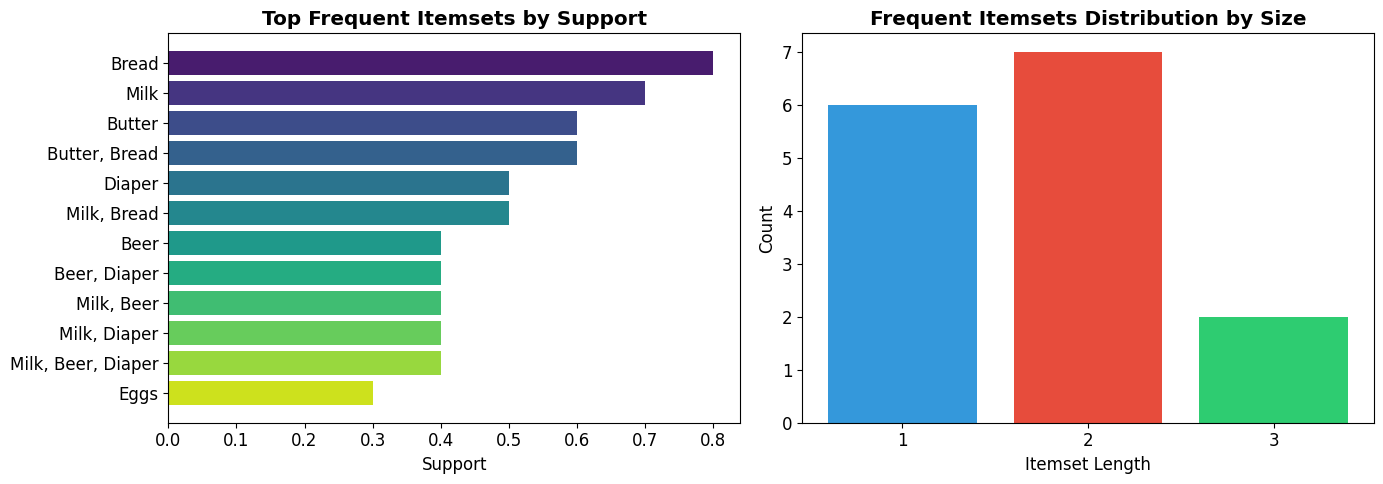

In [7]:
# ── Extract Frequent Itemsets ──
frequent_itemsets = apriori(df_trans, min_support=0.3, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print('Frequent Itemsets (min_support = 0.3):')
print(frequent_itemsets.sort_values('support', ascending=False).to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
top_itemsets = frequent_itemsets.nlargest(12, 'support')
labels = [', '.join(list(x)) for x in top_itemsets['itemsets']]
ax1.barh(labels, top_itemsets['support'], color=sns.color_palette('viridis', len(labels)))
ax1.set_xlabel('Support')
ax1.set_title('Top Frequent Itemsets by Support', fontweight='bold')
ax1.invert_yaxis()

length_counts = frequent_itemsets['length'].value_counts().sort_index()
ax2.bar(length_counts.index, length_counts.values, color=['#3498db', '#e74c3c', '#2ecc71'])
ax2.set_xlabel('Itemset Length')
ax2.set_ylabel('Count')
ax2.set_title('Frequent Itemsets Distribution by Size', fontweight='bold')
ax2.set_xticks(length_counts.index)

plt.tight_layout()
plt.show()


---
## 4. FP-Growth: Frequent Pattern Growth

### 🚀 The Bottleneck of Apriori & Solution

Apriori suffers from computational overhead due to repeated database passes and massive candidate generation. **FP-Growth** compresses the transaction database into an **FP-Tree (Frequent Pattern Tree)**.

### ⚡ Advantages of FP-Growth

| Feature | Apriori | FP-Growth |
|---------|---------|----------|
| Database Scans | $k$ scans (for $k$-length itemsets) | **Exactly 2 database scans** |
| Candidate Generation | Generates explicit candidate itemsets | **No candidate generation required** |
| Data Structure | Flat arrays / candidate hash trees | Prefix Tree (FP-Tree) |
| Computational Speed | Slower on large transaction logs | **Significantly faster** |


In [8]:
# ── FP-Growth Execution ──
from mlxtend.frequent_patterns import fpgrowth

fp_itemsets = fpgrowth(df_trans, min_support=0.3, use_colnames=True)
fp_itemsets['length'] = fp_itemsets['itemsets'].apply(len)

print('FP-Growth Frequent Itemsets (min_support = 0.3):')
print(fp_itemsets.sort_values('support', ascending=False).to_string(index=False))

apriori_set = set(frozenset(x) for x in frequent_itemsets['itemsets'])
fp_set = set(frozenset(x) for x in fp_itemsets['itemsets'])
print(f'\nVerification — Apriori & FP-Growth outputs match: {apriori_set == fp_set}')


FP-Growth Frequent Itemsets (min_support = 0.3):
 support              itemsets  length
     0.8               (Bread)       1
     0.7                (Milk)       1
     0.6              (Butter)       1
     0.6       (Butter, Bread)       2
     0.5              (Diaper)       1
     0.5         (Milk, Bread)       2
     0.4                (Beer)       1
     0.4  (Milk, Beer, Diaper)       3
     0.4        (Milk, Diaper)       2
     0.4          (Milk, Beer)       2
     0.4        (Beer, Diaper)       2
     0.3                (Eggs)       1
     0.3        (Milk, Butter)       2
     0.3 (Milk, Butter, Bread)       3
     0.3       (Diaper, Bread)       2

Verification — Apriori & FP-Growth outputs match: True


---
## 5. Association Rule Mining & Metric Evaluation


In [9]:
# ── Generate Association Rules ──
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)

rules_display = rules[['antecedents', 'consequents', 'support', 'confidence',
                       'lift', 'conviction', 'leverage']].copy()
rules_display['antecedents'] = rules_display['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_display['consequents'] = rules_display['consequents'].apply(lambda x: ', '.join(list(x)))

print('Top Extracted Association Rules (Ranked by Lift):')
print(rules_display.round(3).to_string(index=False))


Top Extracted Association Rules (Ranked by Lift):
 antecedents  consequents  support  confidence  lift  conviction  leverage
        Beer Milk, Diaper      0.4       1.000 2.500         inf      0.24
Milk, Diaper         Beer      0.4       1.000 2.500         inf      0.24
      Diaper         Beer      0.4       0.800 2.000       3.000      0.20
        Beer       Diaper      0.4       1.000 2.000         inf      0.20
      Diaper   Milk, Beer      0.4       0.800 2.000       3.000      0.20
  Milk, Beer       Diaper      0.4       1.000 2.000         inf      0.20
Beer, Diaper         Milk      0.4       1.000 1.429         inf      0.12
        Milk Beer, Diaper      0.4       0.571 1.429       1.400      0.12
        Milk         Beer      0.4       0.571 1.429       1.400      0.12
        Beer         Milk      0.4       1.000 1.429         inf      0.12
Milk, Butter        Bread      0.3       1.000 1.250         inf      0.06
      Butter        Bread      0.6       1.000 1.2

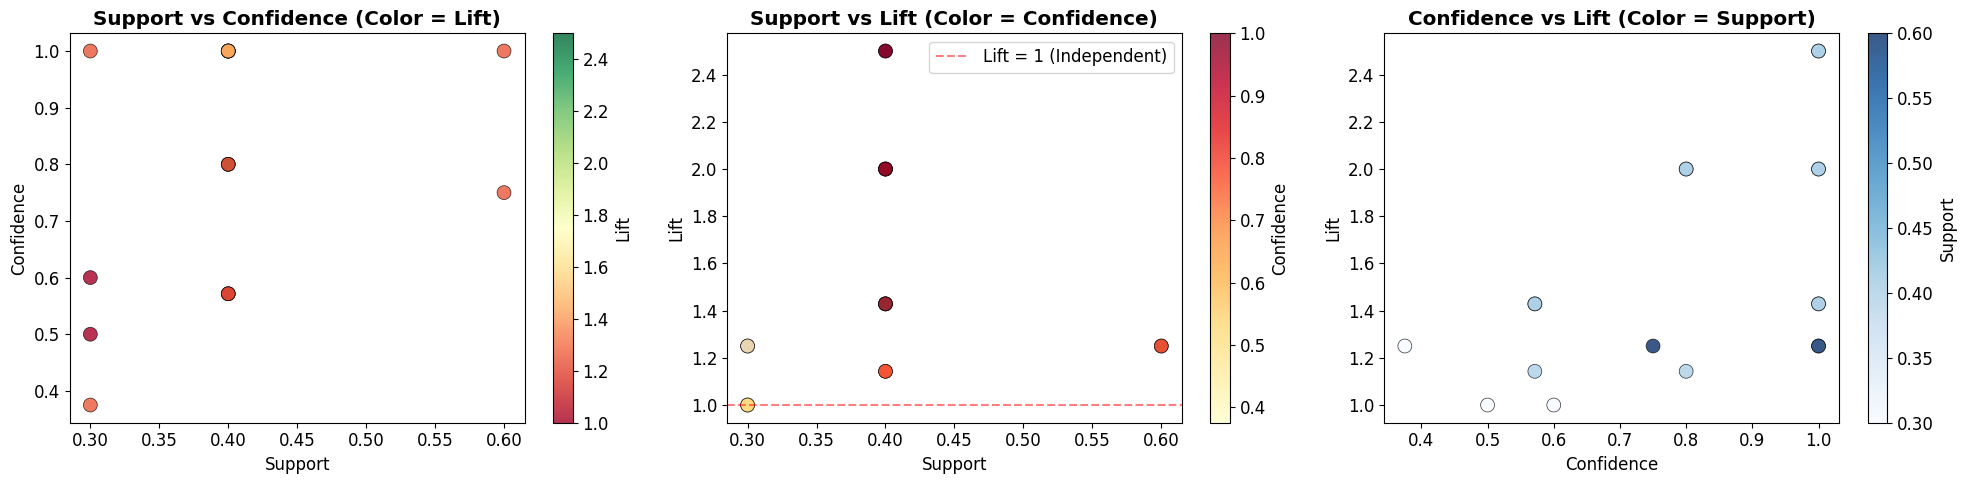

In [10]:
# ── Rule Metric Plots ──
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

scatter1 = axes[0].scatter(rules['support'], rules['confidence'],
                           c=rules['lift'], cmap='RdYlGn', s=100,
                           edgecolors='black', linewidth=0.5, alpha=0.8)
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Support vs Confidence (Color = Lift)', fontweight='bold')
plt.colorbar(scatter1, ax=axes[0], label='Lift')

scatter2 = axes[1].scatter(rules['support'], rules['lift'],
                           c=rules['confidence'], cmap='YlOrRd', s=100,
                           edgecolors='black', linewidth=0.5, alpha=0.8)
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Lift')
axes[1].set_title('Support vs Lift (Color = Confidence)', fontweight='bold')
axes[1].axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Lift = 1 (Independent)')
axes[1].legend()
plt.colorbar(scatter2, ax=axes[1], label='Confidence')

scatter3 = axes[2].scatter(rules['confidence'], rules['lift'],
                           c=rules['support'], cmap='Blues', s=100,
                           edgecolors='black', linewidth=0.5, alpha=0.8)
axes[2].set_xlabel('Confidence')
axes[2].set_ylabel('Lift')
axes[2].set_title('Confidence vs Lift (Color = Support)', fontweight='bold')
plt.colorbar(scatter3, ax=axes[2], label='Support')

plt.tight_layout()
plt.show()


---
## 6. Co-occurrence Matrix Heatmap


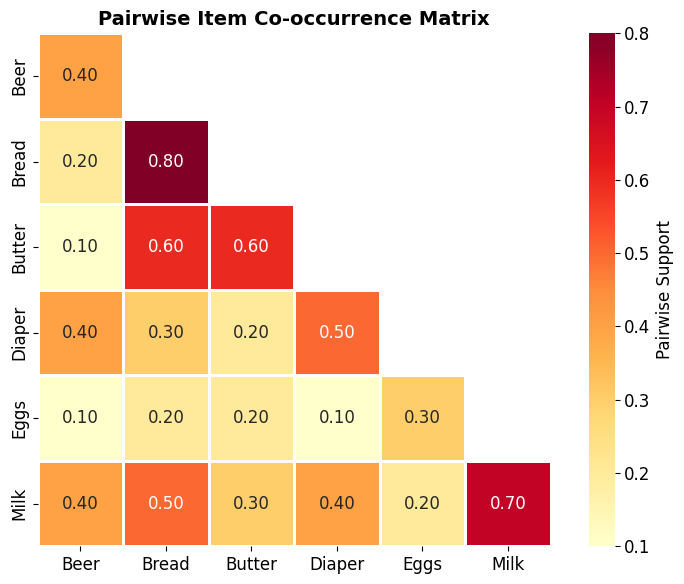

In [11]:
# ── Pairwise Item Co-occurrence Matrix ──
items = sorted(set(item for t in transactions for item in t))
cooccurrence = pd.DataFrame(0.0, index=items, columns=items)

for item_a in items:
    for item_b in items:
        cooccurrence.loc[item_a, item_b] = get_support([item_a, item_b], transactions)

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(cooccurrence, dtype=bool), k=1)
sns.heatmap(cooccurrence, annot=True, fmt='.2f', cmap='YlOrRd',
            mask=mask, square=True, linewidths=1,
            cbar_kws={'label': 'Pairwise Support'})
plt.title('Pairwise Item Co-occurrence Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()


---
## 📝 Key Takeaways

1. **Support**: Measures absolute itemset popularity across all transactions.
2. **Confidence**: Conditional probability $P(B|A)$; can be misleading if $B$ has high individual support.
3. **Lift**: Corrects for baseline item popularity; values $> 1$ indicate strong positive association.
4. **Apriori**: Prunes search space using subset anti-monotonicity; requires $k$ database scans.
5. **FP-Growth**: Eliminates candidate generation via FP-Trees; executes in 2 database scans.
